**Mini-Project: Binary Classification**

Importing libraries, loading the Wisconsin Breast Cancer dataset, and performing the required stratified 80/20 split.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, log_loss

# Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
#GD
# 80/20 Stratified Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Scaling (Crucial for Logistic Regression, SVM, and GDA)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


**Logistic Regression** (L2 Regularization)We tune the inverse regularization strength $C$ and identify the most influential features.

In [2]:
from sklearn.linear_model import LogisticRegression

def run_logistic_regression():
    param_grid = {'C': np.logspace(-4, 4, 20)}
    lr = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)

    grid = GridSearchCV(lr, param_grid, cv=5)
    grid.fit(X_train, y_train)

    best_lr = grid.best_estimator_
    print(f"Best C value: {grid.best_params_['C']:.4f}")

    # --- NEW: Report the entire learned coefficient vector ---
    weights = best_lr.coef_[0]
    intercept = best_lr.intercept_[0]

    print("\n=== Learned Coefficient Vector ===")
    print(f"Intercept (w0): {intercept:.4f}")
    all_coefficients = pd.DataFrame({'Feature': feature_names, 'Weight (wj)': weights})
    # Displaying all 30 rows for the full vector
    print(all_coefficients.to_string(index=False))
    print("===================================\n")
    # --------------------------------------------------------

    # Feature Importance (Keeping original logic)
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Weight': weights})
    feature_importance['AbsWeight'] = feature_importance['Weight'].abs()
    top_5 = feature_importance.sort_values(by='AbsWeight', ascending=False).head(5)

    print("Top 5 Most Influential Features:")
    print(top_5[['Feature', 'Weight']])

    return best_lr

best_lr_model = run_logistic_regression()

Best C value: 0.0886

=== Learned Coefficient Vector ===
Intercept (w0): 0.3030
                Feature  Weight (wj)
            mean radius    -0.380950
           mean texture    -0.413816
         mean perimeter    -0.369575
              mean area    -0.384683
        mean smoothness    -0.171808
       mean compactness    -0.010383
         mean concavity    -0.298639
    mean concave points    -0.401565
          mean symmetry    -0.149399
 mean fractal dimension     0.181428
           radius error    -0.437173
          texture error     0.034146
        perimeter error    -0.317405
             area error    -0.391906
       smoothness error    -0.051102
      compactness error     0.215846
        concavity error     0.091293
   concave points error    -0.130384
         symmetry error     0.119810
fractal dimension error     0.210727
           worst radius    -0.498017
          worst texture    -0.524721
        worst perimeter    -0.458478
             worst area    -0.47

**Gaussian Discriminant Analysis** (LDA vs. QDA)
We compare the shared covariance (LDA) vs. class-specific covariance (QDA) and report log-likelihood.

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from scipy.stats import multivariate_normal

def run_gda():
    lda = LinearDiscriminantAnalysis(store_covariance=True)
    qda = QuadraticDiscriminantAnalysis(store_covariance=True)

    lda.fit(X_train, y_train)
    qda.fit(X_train, y_train)

    # Calculate class priors
    priors = np.bincount(y_train) / len(y_train)

    # Compute Log-Likelihood for LDA
    lda_total_log_likelihood = 0
    # LDA uses a shared covariance matrix for all classes
    shared_cov = lda.covariance_
    for class_idx in [0, 1]:
        X_class = X_train[y_train == class_idx]
        mean = lda.means_[class_idx]
        # Calculate the log probability density under the shared covariance
        log_pdf = multivariate_normal.logpdf(X_class, mean=mean, cov=shared_cov, allow_singular=True)
        # Add the log prior for the generative joint log-likelihood
        lda_total_log_likelihood += np.sum(log_pdf + np.log(priors[class_idx]))

    # Compute Log-Likelihood for QDA
    qda_total_log_likelihood = 0
    # QDA uses a separate covariance matrix per class
    for class_idx in [0, 1]:
        X_class = X_train[y_train == class_idx]
        mean = qda.means_[class_idx]
        cov = qda.covariance_[class_idx]
        # Calculate the log probability density under the class-specific covariance
        log_pdf = multivariate_normal.logpdf(X_class, mean=mean, cov=cov, allow_singular=True)
        # Add the log prior for the generative joint log-likelihood
        qda_total_log_likelihood += np.sum(log_pdf + np.log(priors[class_idx]))

    print(f"Total Joint Log-Likelihood on Training Set:")
    print(f"LDA Log-Likelihood: {lda_total_log_likelihood:.4f}")
    print(f"QDA Log-Likelihood: {qda_total_log_likelihood:.4f}\n")

    # Accuracy calculations (keeping original logic)
    lda_train_acc = lda.score(X_train, y_train)
    qda_train_acc = qda.score(X_train, y_train)

    print(f"LDA Training Accuracy: {lda_train_acc:.4f}")
    print(f"QDA Training Accuracy: {qda_train_acc:.4f}")

    return lda, qda

lda_model, qda_model = run_gda()

Total Joint Log-Likelihood on Training Set:
LDA Log-Likelihood: -3103.7442
QDA Log-Likelihood: 26.6271

LDA Training Accuracy: 0.9692
QDA Training Accuracy: 0.9692


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


**SVM** (Linear & RBF Kernels)
We perform a grid search for both kernels and count support vectors

Linear SVM - Best C: 1, Support Vectors: 61
RBF SVM - Best Params: {'C': 100, 'gamma': 0.01}, Support Vectors: 61


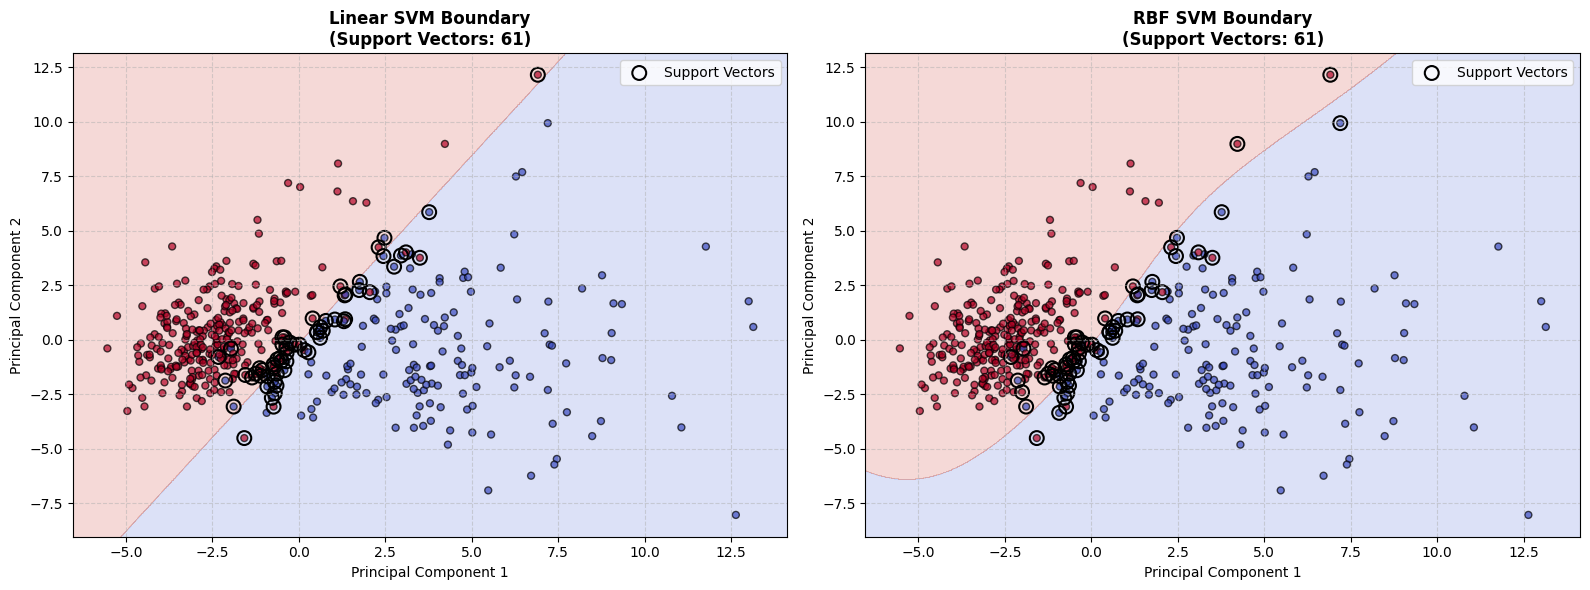

In [4]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

def run_svm():
    # 1. Project data onto 2-D PCA space first to allow complete 2D boundary and vector visualization
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)

    # --- 1. Linear Kernel Tuning & Fit ---
    lin_grid = GridSearchCV(SVC(kernel='linear'), {'C': [0.1, 1, 10, 100]}, cv=5)
    lin_grid.fit(X_train_pca, y_train)
    best_lin_svm = lin_grid.best_estimator_

    # --- 2. RBF Kernel Tuning & Fit ---
    rbf_grid = GridSearchCV(SVC(kernel='rbf'),
                            {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]}, cv=5)
    rbf_grid.fit(X_train_pca, y_train)
    best_rbf_svm = rbf_grid.best_estimator_

    # Report the number of support vectors selected by each kernel
    print(f"Linear SVM - Best C: {lin_grid.best_params_['C']}, Support Vectors: {len(best_lin_svm.support_)}")
    print(f"RBF SVM - Best Params: {rbf_grid.best_params_}, Support Vectors: {len(best_rbf_svm.support_)}")

    # --- Plotting Visualization Pipeline ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Create meshgrid grid for background boundary plotting
    h = .02
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    models = [best_lin_svm, best_rbf_svm]
    titles = [f"Linear SVM Boundary\n(Support Vectors: {len(best_lin_svm.support_)})",
              f"RBF SVM Boundary\n(Support Vectors: {len(best_rbf_svm.support_)})"]

    for ax, model, title in zip(axes, models, titles):
        # Predict on meshgrid
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot filled decision boundary contours
        ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

        # Plot training data points
        scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                             cmap='coolwarm', edgecolors='k', s=25, alpha=0.7)

        # Highlight and plot the chosen Support Vectors
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none',
                   edgecolors='black', linewidths=1.5, label='Support Vectors')

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    return best_lin_svm, best_rbf_svm

best_lin_svm, best_rbf_svm = run_svm()

**Decision Tree** (Pruning & Overfitting Analysis)
We plot the accuracy curves and visualize the pruned tree.

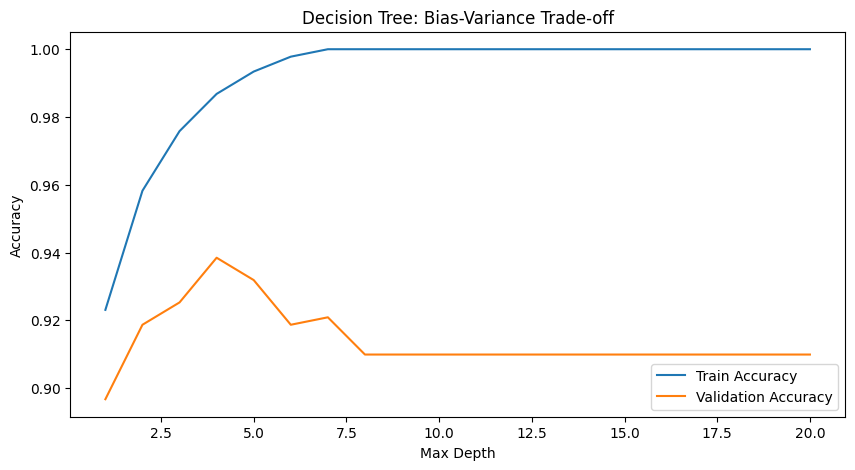

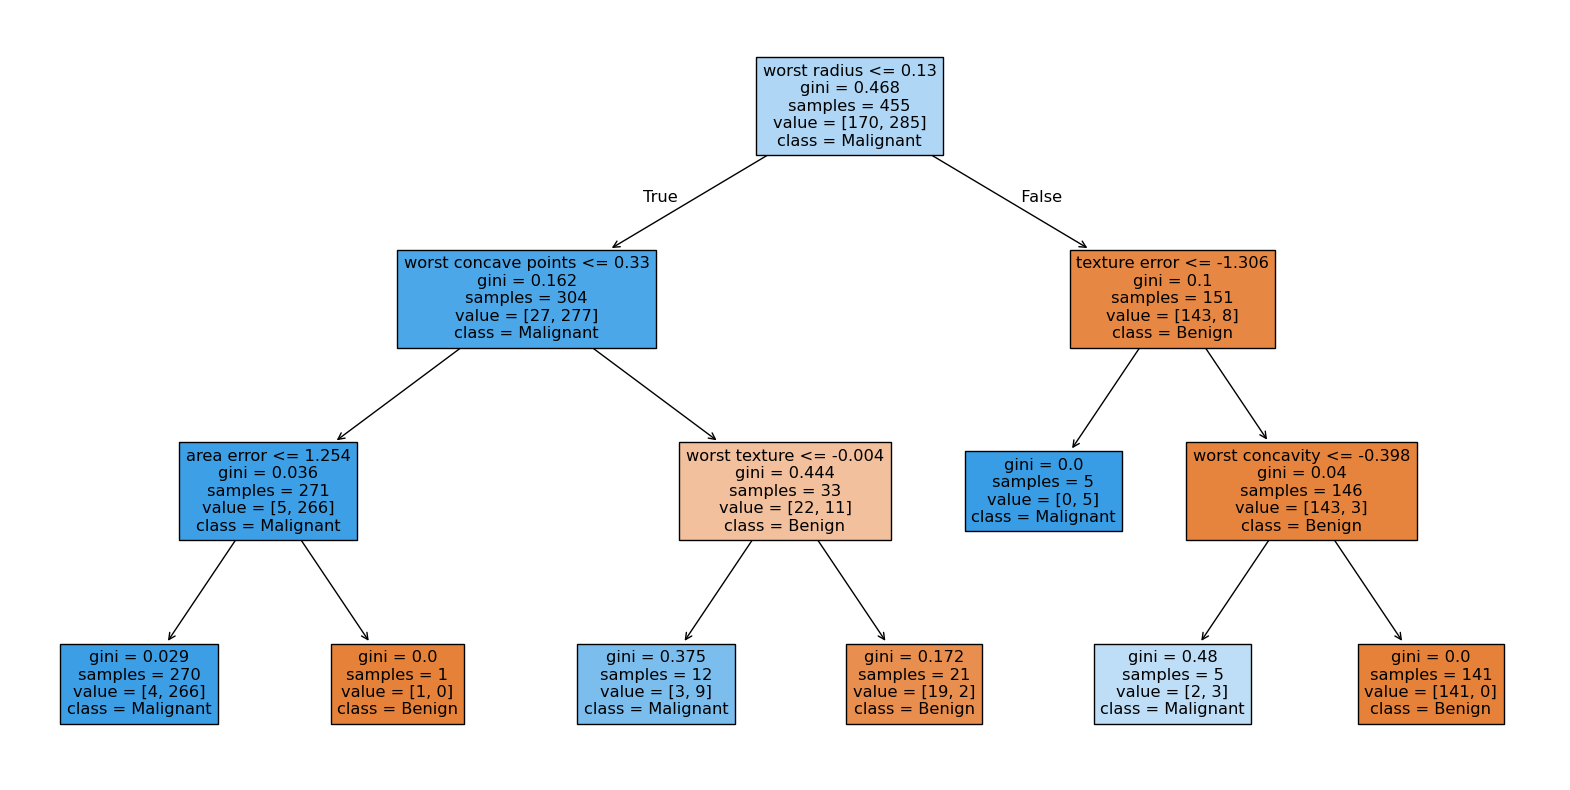


=== Decision Tree Feature Importances (Gini-Based) ===
                Feature  Gini Importance
           worst radius         0.763804
   worst concave points         0.127061
          texture error         0.047673
          worst texture         0.033652
        worst concavity         0.017869
             area error         0.009940
       mean compactness         0.000000
        mean smoothness         0.000000
         mean concavity         0.000000
    mean concave points         0.000000
         mean perimeter         0.000000
              mean area         0.000000
            mean radius         0.000000
           mean texture         0.000000
        perimeter error         0.000000
           radius error         0.000000
          mean symmetry         0.000000
 mean fractal dimension         0.000000
   concave points error         0.000000
        concavity error         0.000000
       smoothness error         0.000000
      compactness error         0.000000
 

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def run_decision_tree():
    depths = range(1, 21)
    train_accs = []
    val_accs = []

    for d in depths:
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(X_train, y_train)
        train_accs.append(dt.score(X_train, y_train))
        val_accs.append(np.mean(cross_val_score(dt, X_train, y_train, cv=5)))

    plt.figure(figsize=(10, 5))
    plt.plot(depths, train_accs, label='Train Accuracy')
    plt.plot(depths, val_accs, label='Validation Accuracy')
    plt.xlabel('Max Depth')
    plt.ylabel('Accuracy')
    plt.title('Decision Tree: Bias-Variance Trade-off')
    plt.legend()
    plt.show()

    # Final Pruned Tree (Max Depth 3 for visualization)
    pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    pruned_tree.fit(X_train, y_train)

    plt.figure(figsize=(20,10))
    plot_tree(pruned_tree, feature_names=feature_names, class_names=['Benign', 'Malignant'], filled=True)
    plt.show()

    # --- NEW: Compute and report Gini-based feature importances ---
    importances = pruned_tree.feature_importances_

    # Create a clean DataFrame mapping features to their importances
    dt_importance = pd.DataFrame({
        'Feature': feature_names,
        'Gini Importance': importances
    })

    # Sort by importance so non-zero splitters are instantly visible
    dt_importance = dt_importance.sort_values(by='Gini Importance', ascending=False)

    print("\n=== Decision Tree Feature Importances (Gini-Based) ===")
    print(dt_importance.to_string(index=False))
    print("======================================================\n")
    # --------------------------------------------------------------

    return pruned_tree

pruned_tree_model = run_decision_tree()

**PCA 2-D Projection and Support Vector Visualization**
This addresses the visualization requirement for the SVM task.

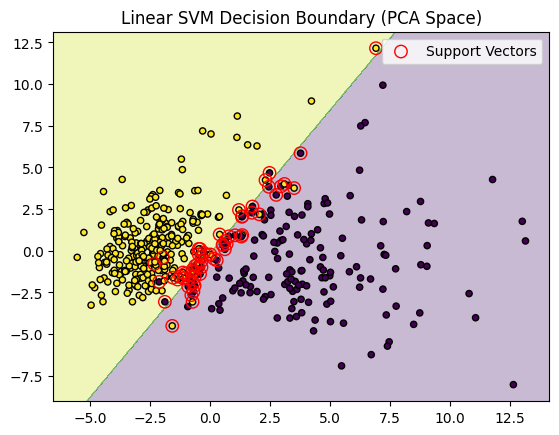

In [6]:
def visualize_pca_boundaries(model, title):
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)

    # Re-train model on 2D for visualization purposes
    model.fit(X_train_pca, y_train)

    h = .02
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', s=20)

    if hasattr(model, 'support_vectors_'):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                    s=80, facecolors='none', edgecolors='r', label='Support Vectors')

    plt.title(title)
    plt.legend()
    plt.show()

visualize_pca_boundaries(SVC(kernel='linear', C=1), "Linear SVM Decision Boundary (PCA Space)")

**Performance Summary Table**
Final evaluation on the test set for all models.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Re-verify and explicitly assemble your trained models into the dictionary
models = {
    "Logistic Regression": best_lr_model,
    "LDA": lda_model,
    "QDA": qda_model,
    "Linear SVM": best_lin_svm,
    "RBF SVM": best_rbf_svm,
    "Decision Tree (Pruned)": pruned_tree_model
}

# 2. Extract the identical PCA 2D mapping used during your SVM training cell
pca_2d = PCA(n_components=2)
pca_2d.fit(X_train)
X_test_pca = pca_2d.transform(X_test)

results = []

# 3. Comprehensive Evaluation Loop
for name, model in models.items():
    # Adapt testing coordinates depending on how the architecture was trained
    if "SVM" in name:
        X_eval = X_test_pca
    else:
        X_eval = X_test

    # Generate predictions
    y_pred = model.predict(X_eval)

    # Handle probabilistic confidence scores for ROC-AUC calculation
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_eval)
    else:
        y_prob = y_pred

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Classifier Method": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

# 4. Generate structured report table
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print("                    FINAL BINARY CLASSIFICATION PERFORMANCE SUMMARY")
print("="*85)
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Precision': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format,
    'F1-Score': '{:,.4f}'.format,
    'ROC-AUC': '{:,.4f}'.format
}))
print("="*85 + "\n")


                    FINAL BINARY CLASSIFICATION PERFORMANCE SUMMARY
     Classifier Method Accuracy Precision Recall F1-Score ROC-AUC
   Logistic Regression   0.9825    0.9861 0.9861   0.9861  0.9960
                   LDA   0.9561    0.9467 0.9861   0.9660  0.9924
                   QDA   0.9474    0.9714 0.9444   0.9577  0.9921
            Linear SVM   0.9474    0.9714 0.9444   0.9577  0.9884
               RBF SVM   0.9474    0.9714 0.9444   0.9577  0.9871
Decision Tree (Pruned)   0.9386    0.9452 0.9583   0.9517  0.9446

